In [2]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json
from qiskit.quantum_info import SparsePauliOp
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters

In [3]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

In [4]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

### KLVFFA_6AAs MPS run
- $R^2 = 0.999$
- 100k shots
- 500 COBYLA iterations

In [49]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

main_seq = "KLVFFA" # 6MVZ
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.99999, chunk=20)

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.00040411949157714844
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003261566162109375
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00027489662170410156
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.0002810955047607422
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.00028896331787109375
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.00026297569274902344
h_op size @ k = 7: 64
Time taken to do composition @ k = 8: 0.0003771781921386719
h_op size @ k = 8: 64
Time taken to do composition @ k = 9: 0.00030112266540527344
h_op size @ k = 9: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.0032529830932617188
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.007578849792480469
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.008169174194335938
h

In [6]:
import os
import json

# Base path format — update if your timestamp or base path is different
base_path_template = "../res/fcc_hw/KLVFFA_2025-05-15-19-51-03_aer_simulator_matrix_product_state_interval{}"

# Create dictionaries to store metadata and opt_results
all_metadata = {}
all_opt_results = {}

# Loop over the 4 intervals
for i in range(1, 5):
    res_dir = base_path_template.format(i)
    metadata_path = os.path.join(res_dir, "metadata.json")
    opt_res_path = os.path.join(res_dir, "opt_results.json")

    with open(metadata_path, "r") as f:
        all_metadata[i] = json.load(f)

    with open(opt_res_path, "r") as f:
        all_opt_results[i] = json.load(f)

print("✅ Loaded metadata and optimization results for all intervals.")


✅ Loaded metadata and optimization results for all intervals.


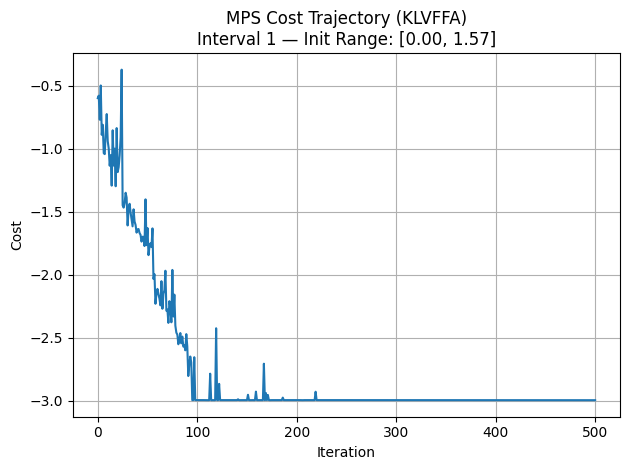

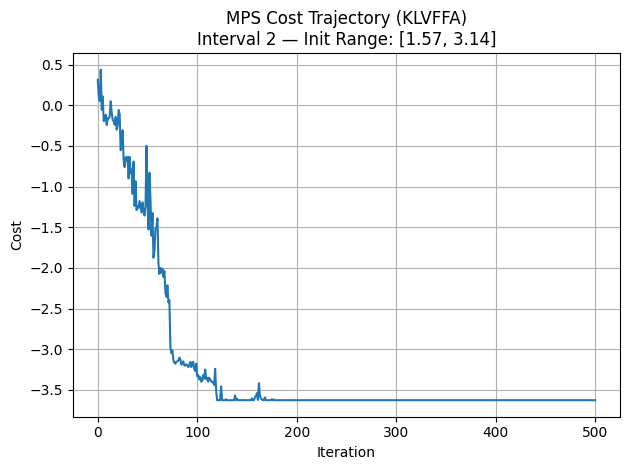

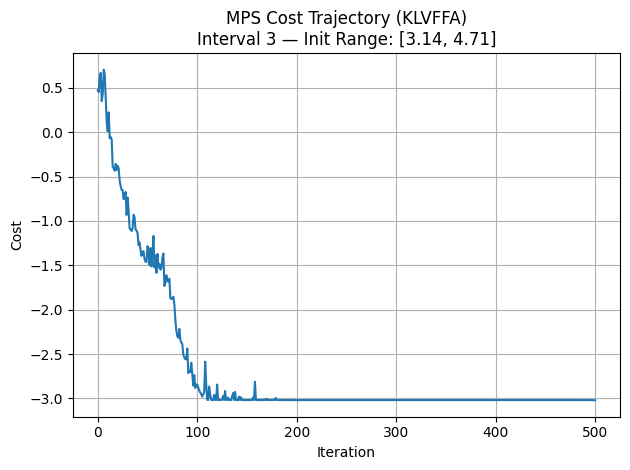

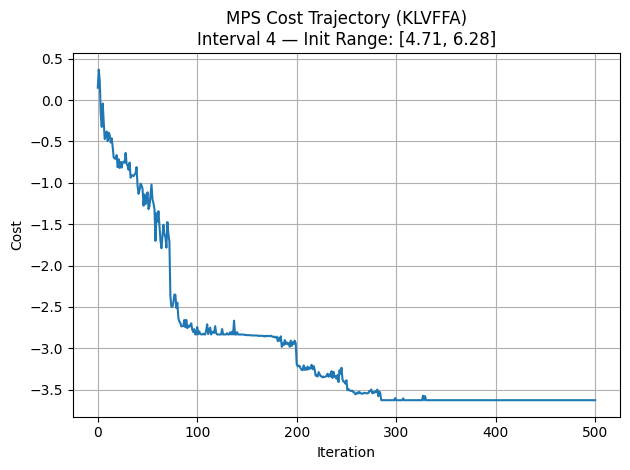

In [15]:
import matplotlib.pyplot as plt

for i in range(1, 5):
    opt_res = all_opt_results[i]
    metadata = all_metadata[i]

    plt.figure()
    plt.plot(opt_res["cost_trajectory"])
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title(f"MPS Cost Trajectory (KLVFFA)\nInterval {i} — Init Range: {metadata['init_param_interval']}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [9]:
# Dictionary to store top 100 solutions per interval
top_mps_solns_by_interval = {}

for i in range(1, 5):
    opt_res = all_opt_results[i]
    metadata = all_metadata[i]
    
    top_100 = opt_res["top_solutions"][:100]

    top_mps_solns = [
        [convert_bitstring_to_turns(bitstring, metadata["main_seq"]), bitstring, energy]
        for bitstring, energy in top_100
    ]
    
    top_mps_solns_by_interval[i] = top_mps_solns

# Example: preview first 5 results from interval 1
top_mps_solns_by_interval[1][:10]


[['81490', '101101010100011100100110', -3.4960534272310184],
 ['05180', '110101011000001010110001', -3.457548494465925],
 ['09380', '111010000000000010111101', -3.333842955139861],
 ['16380', '111100000011000101111101', -3.3314999294410685],
 ['0a180', '001011001000001101110001', -3.2660309433137407],
 ['81490', '101101010000011100100110', -3.247053427231018],
 ['13680', '111101100011001111010101', -3.2256525415337842],
 ['0a180', '011111001000001101110001', -3.17903094331374],
 ['15800', '001100000011001010000100', -3.1622547629969016],
 ['05180', '110101001000001010110001', -3.1215484944659253]]

In [10]:
for i in range(1, 5):
    top_mps_solns = top_mps_solns_by_interval[i]
    
    # Convert each turn sequence (a list) to a tuple so it can go in a set
    unique_turns = set(tuple(sol[0]) for sol in top_mps_solns)
    
    print(f"Interval {i} — Init Range {all_metadata[i]['init_param_interval']}: {len(unique_turns)} unique turn sequences")



Interval 1 — Init Range [0.00, 1.57]: 56 unique turn sequences
Interval 2 — Init Range [1.57, 3.14]: 26 unique turn sequences
Interval 3 — Init Range [3.14, 4.71]: 37 unique turn sequences
Interval 4 — Init Range [4.71, 6.28]: 31 unique turn sequences


In [11]:
# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:100]
top_cls_solns[:10]

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33]]

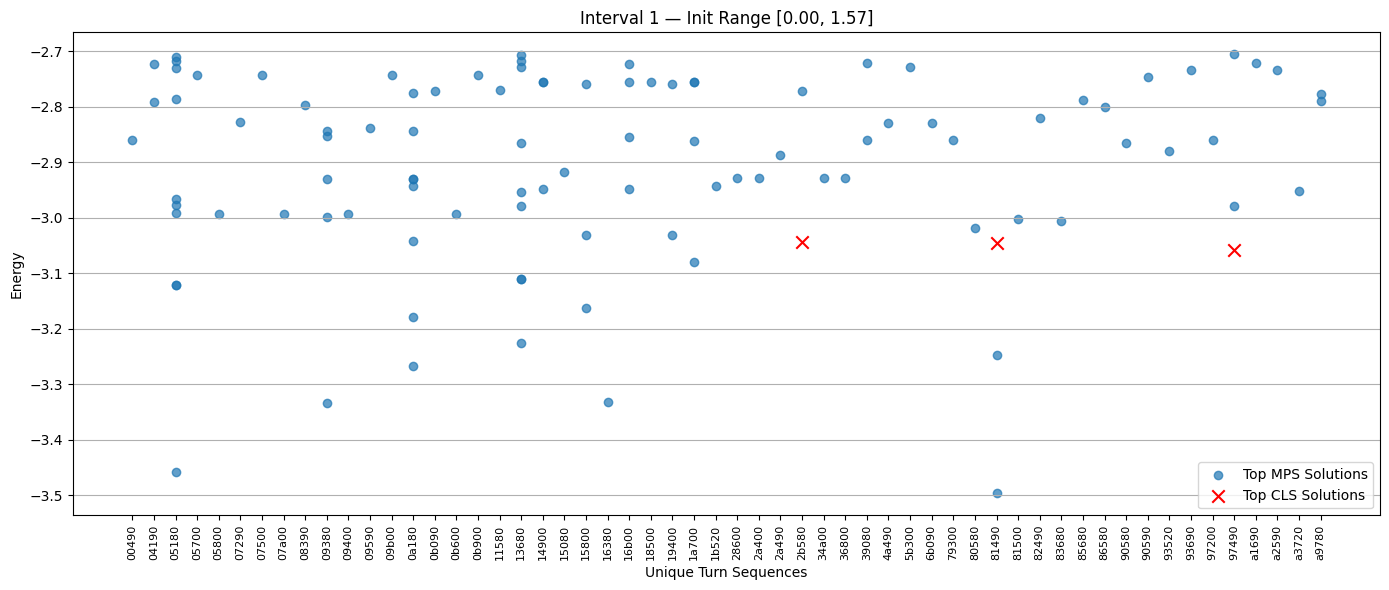

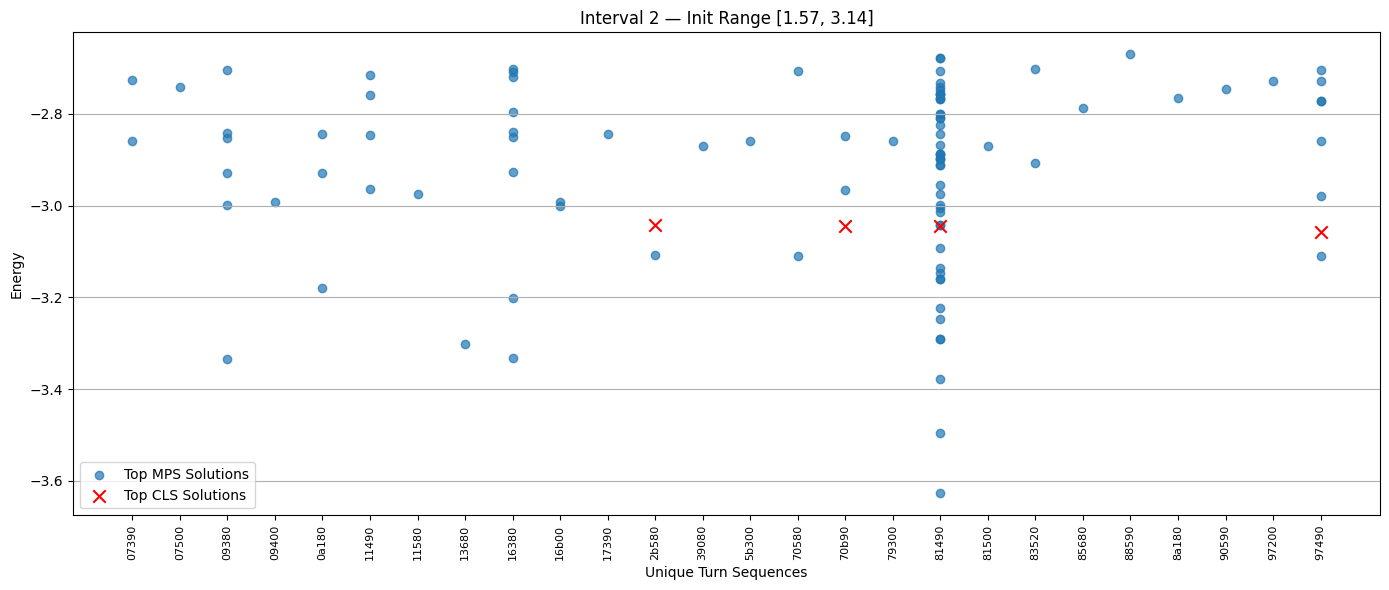

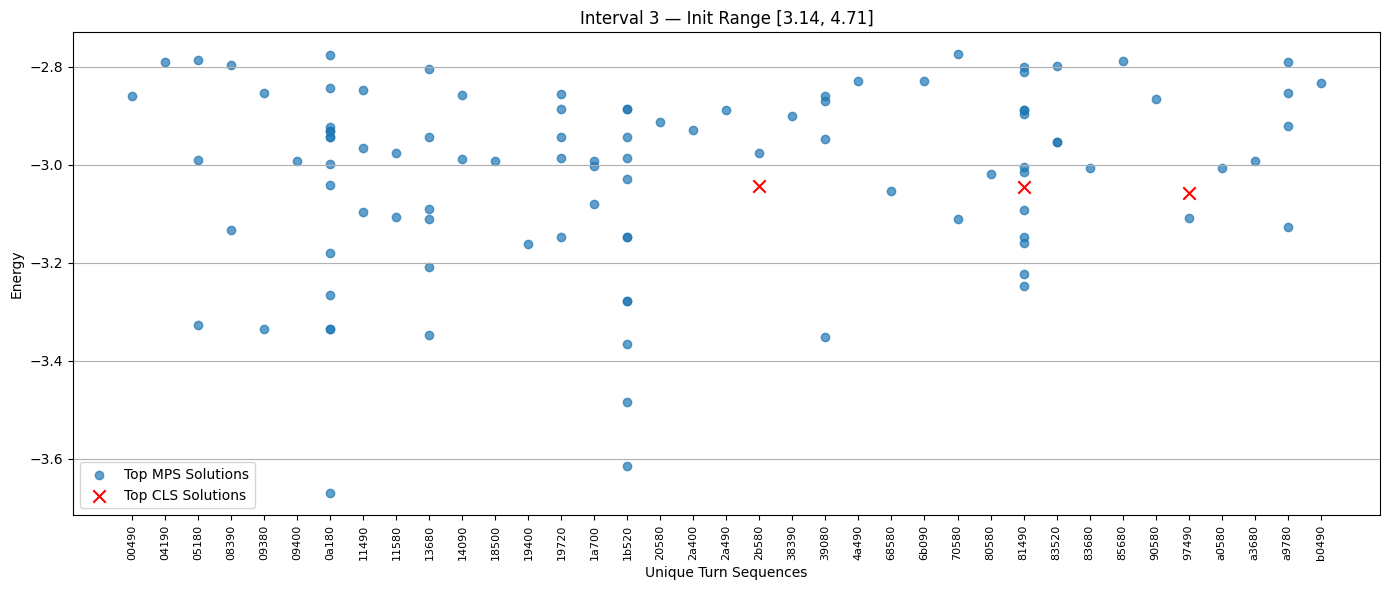

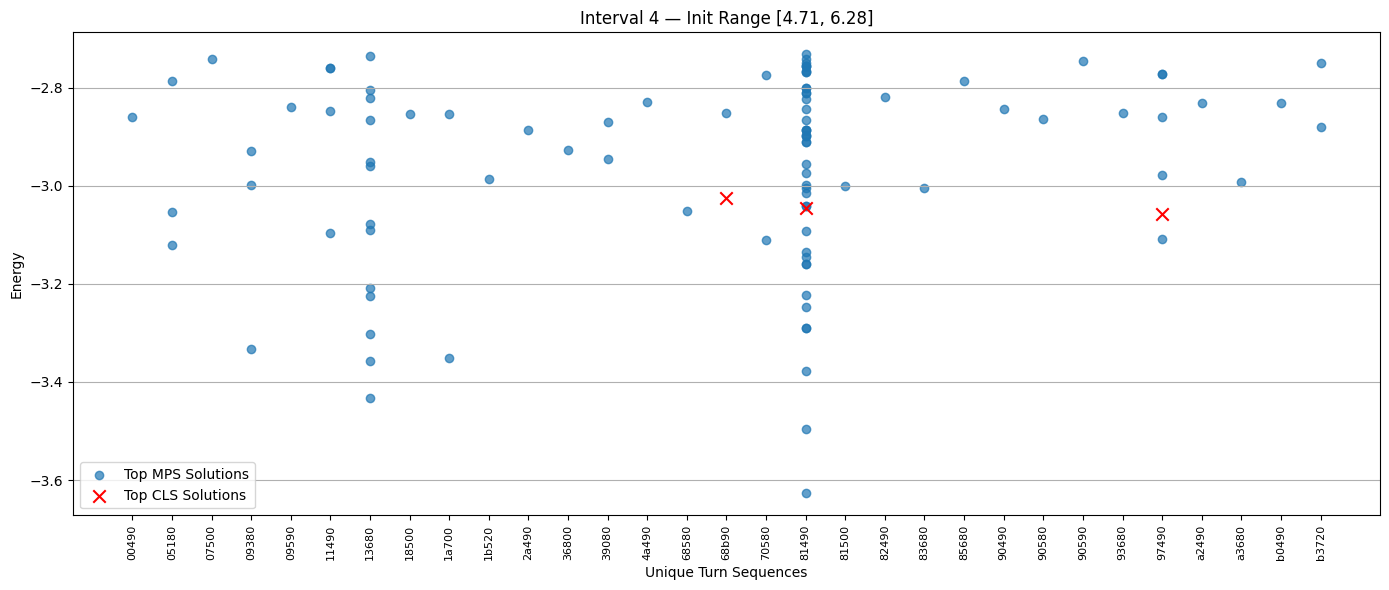

In [20]:
from collections import defaultdict
import matplotlib.pyplot as plt

for i in range(1, 5):
    top_mps_solns = top_mps_solns_by_interval[i]
    metadata = all_metadata[i]
    
    turn_seq_energy_dict = defaultdict(list)
    
    # Build energy list for each unique turn sequence
    for turn_seq, bitstring, energy in top_mps_solns:
        turn_seq_str = ''.join(turn_seq)
        turn_seq_energy_dict[turn_seq_str].append(energy)
    
    sorted_turns = sorted(turn_seq_energy_dict.keys())
    
    x_vals = []
    y_vals = []
    
    for idx, turn in enumerate(sorted_turns):
        energies = turn_seq_energy_dict[turn]
        x_vals.extend([idx] * len(energies))
        y_vals.extend(energies)
    
    turn_seq_to_index = {turn_seq: idx for idx, turn_seq in enumerate(sorted_turns)}
    
    plt.figure(figsize=(14, 6))
    plt.scatter(x_vals, y_vals, alpha=0.7, label='Top MPS Solutions')
    
    # Overlay CLS solutions (scaled)
    for turn_str, energy in top_cls_solns:
        scaled_energy = energy / 10
        if turn_str in turn_seq_to_index:
            x_idx = turn_seq_to_index[turn_str]
            plt.scatter(x_idx, scaled_energy, color='red', marker='x', s=80, label='Top CLS Solutions')

    # Deduplicate legend
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    plt.legend(unique_labels.values(), unique_labels.keys())

    # Final plot formatting
    plt.xticks(ticks=range(len(sorted_turns)), labels=sorted_turns, rotation=90, fontsize=8)
    plt.xlabel("Unique Turn Sequences")
    plt.ylabel("Energy")
    plt.title(f"Interval {i} — Init Range {metadata['init_param_interval']}")
    plt.tight_layout()
    plt.grid(True, axis='y')
    plt.show()


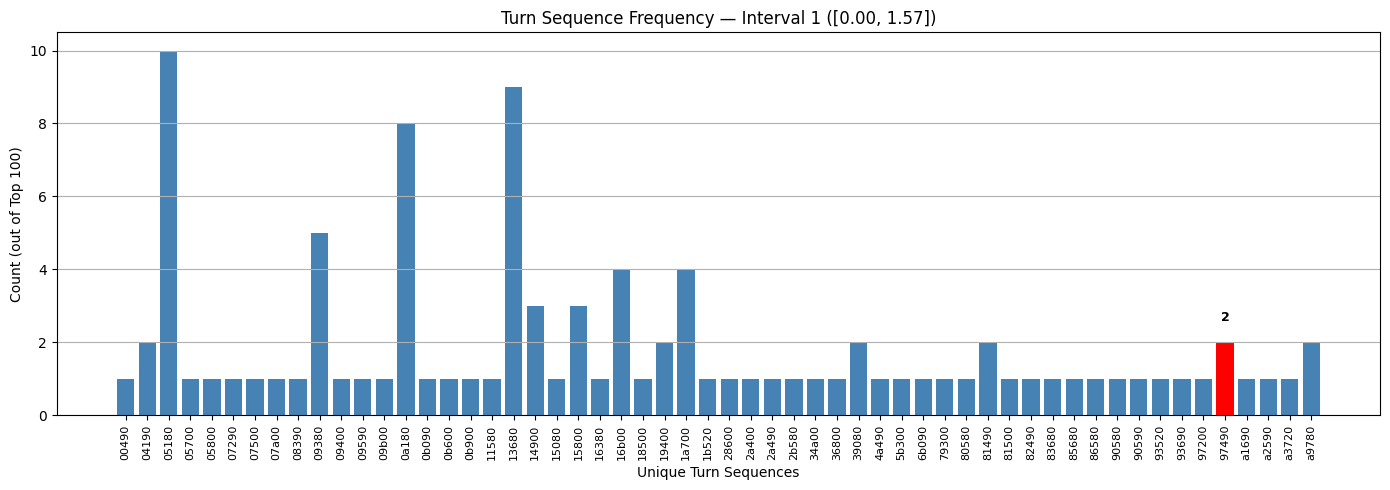

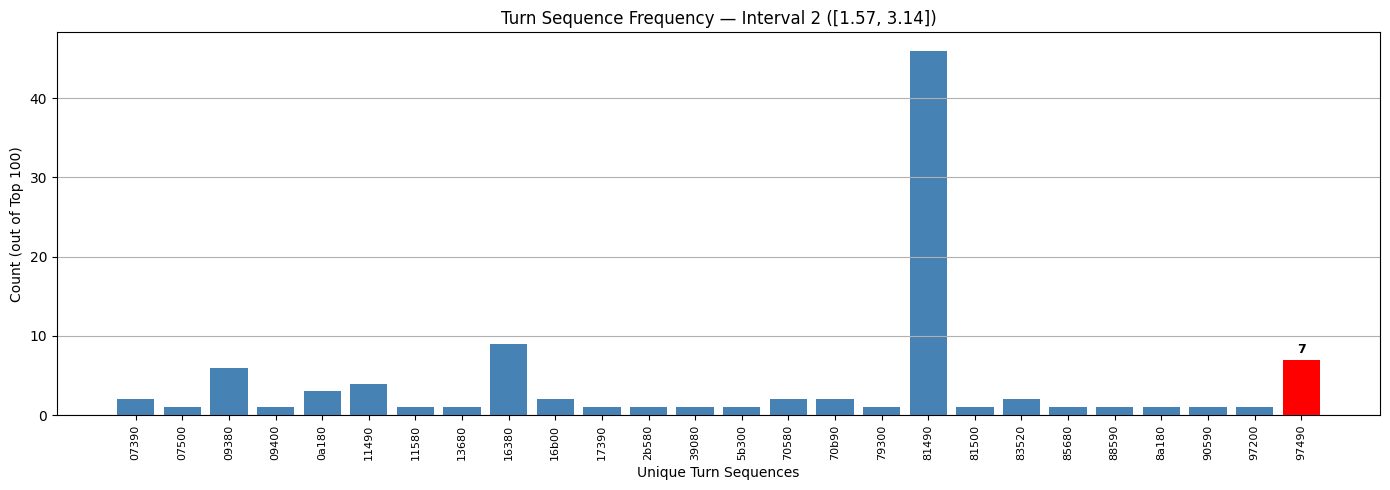

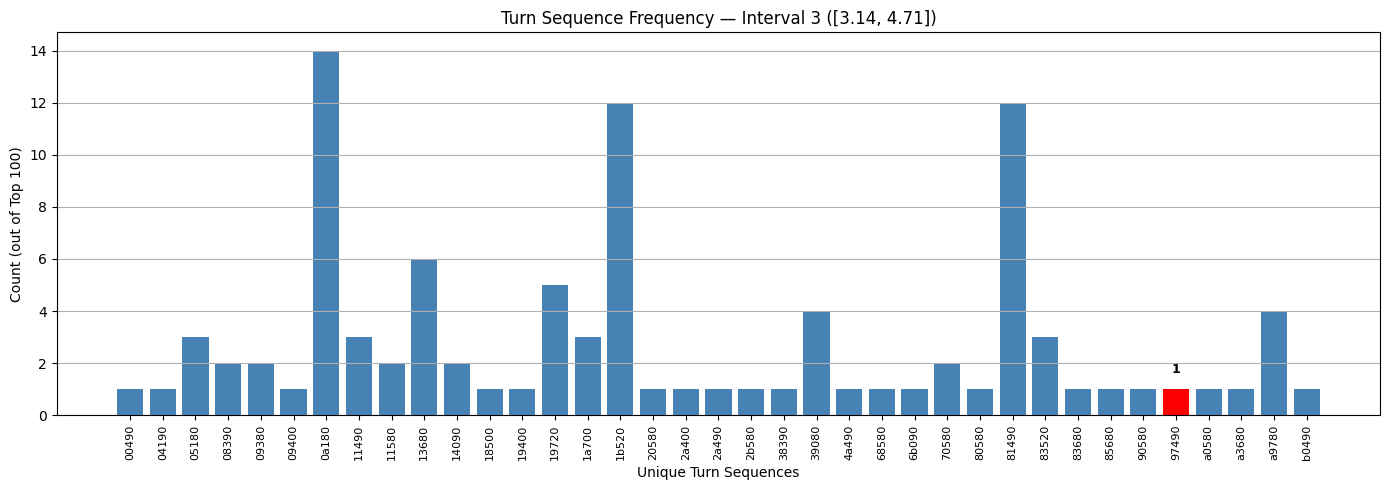

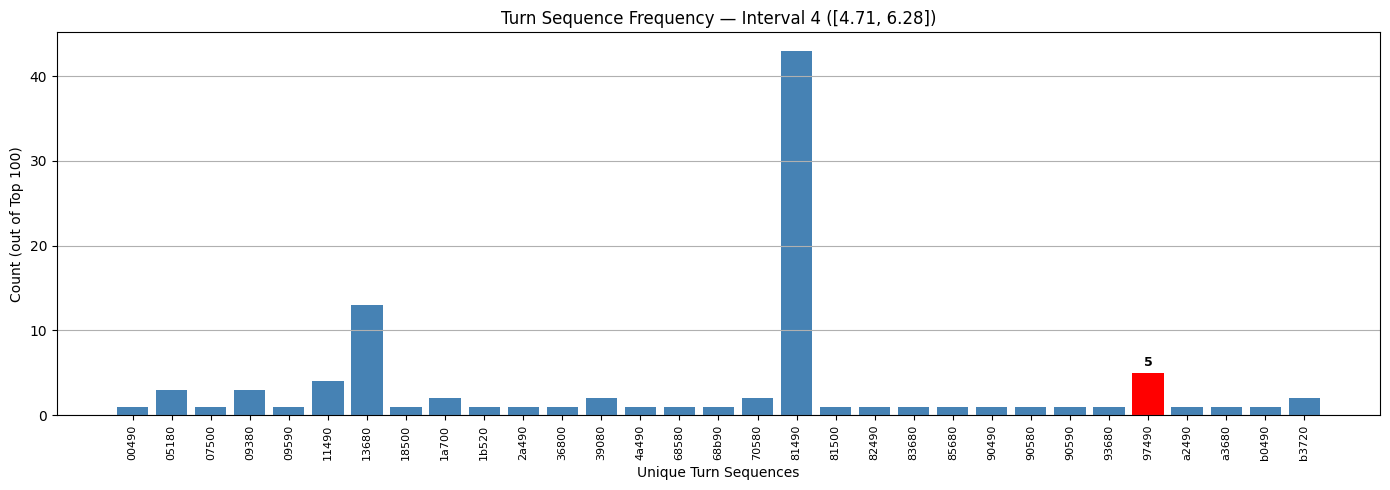

In [23]:
from collections import Counter
import matplotlib.pyplot as plt

# Top 3 classical solutions to highlight
cls_top3 = {'97490', 'a9720', '8b520'}

for i in range(1, 5):
    top_mps_solns = top_mps_solns_by_interval[i]
    metadata = all_metadata[i]
    
    # Extract turn sequences as strings
    turn_strs = [''.join(sol[0]) for sol in top_mps_solns]
    
    # Count occurrences
    turn_counts = Counter(turn_strs)
    sorted_turns = sorted(turn_counts.keys())
    
    x_vals = list(range(len(sorted_turns)))
    y_vals = [turn_counts[turn] for turn in sorted_turns]
    
    # Color bars: red for top-3 CLS, blue otherwise
    bar_colors = ['red' if turn in cls_top3 else 'steelblue' for turn in sorted_turns]
    
    # Plot
    plt.figure(figsize=(14, 5))
    bars = plt.bar(x_vals, y_vals, color=bar_colors)
    
    # Annotate red bars with count
    for idx, turn in enumerate(sorted_turns):
        if turn in cls_top3:
            count = turn_counts[turn]
            plt.text(x_vals[idx], y_vals[idx] + 0.5, str(count), ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')
    
    plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
    plt.xlabel("Unique Turn Sequences")
    plt.ylabel("Count (out of Top 100)")
    plt.title(f"Turn Sequence Frequency — Interval {i} ({metadata['init_param_interval']})")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


In [43]:
from fcc import ProteinShapeDecoder, ProteinShapeFileGen
from fcc.fcc_protein_shape import turns_to_bitstring
from fcc.measurement_utils import _evaluate_sparsepauli

[('13680', -3.8376525417653227), ('0a180', -3.6700309438362595), ('81490', -3.6270534270172496), ('1b520', -3.6146525416236788), ('1a700', -3.4827315214267225), ('14900', -3.4827315213983727), ('16b00', -3.4827315213479286), ('18500', -3.482731521347662), ('05180', -3.4575484945286084), ('39080', -3.350320099122894), ('09380', -3.3338429551988664), ('16380', -3.331499929712166), ('a3720', -3.288207893508075), ('a9780', -3.2572078938768216), ('19400', -3.162254762870637), ('15800', -3.1622547628445226), ('08390', -3.132842955449254), ('04190', -3.1265484942402653), ('97490', -3.109165880986775), ('2b580', -3.106748202778982), ('11580', -3.1062547628596153), ('15080', -3.04794953882346), ('80580', -3.017594513997148), ('83680', -3.005253913314754), ('81500', -3.001286873639309), ('0b600', -2.9929262625932456), ('07a00', -2.9929262625921202), ('05800', -2.992926262268063), ('09400', -2.992926262124449), ('34a00', -2.927939126633701), ('28600', -2.9279391263555805), ('2a400', -2.9279391263

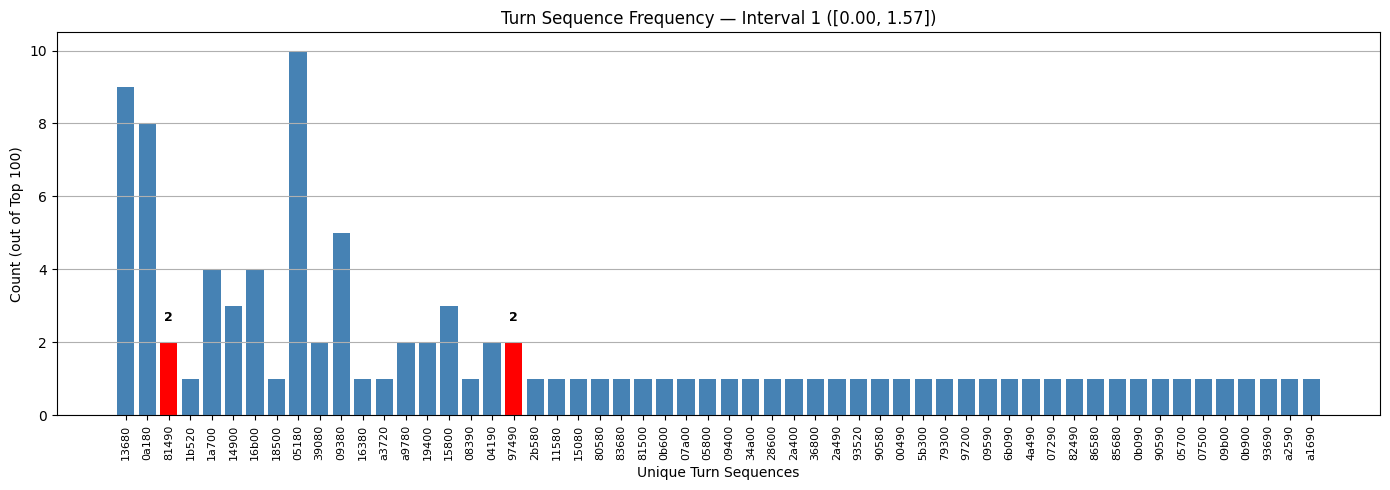

[('13680', -3.8376525417653227), ('0a180', -3.6700309438362595), ('81490', -3.6270534270172496), ('16b00', -3.4827315213479286), ('39080', -3.350320099122894), ('09380', -3.3338429551988664), ('16380', -3.331499929712166), ('83520', -3.2882078939640476), ('70580', -3.1101955864654074), ('97490', -3.109165880986775), ('2b580', -3.106748202778982), ('11580', -3.1062547628596153), ('70b90', -3.097165881107503), ('11490', -3.095731521524678), ('81500', -3.001286873639309), ('09400', -2.992926262124449), ('17390', -2.975499929575501), ('5b300', -2.85922108227913), ('79300', -2.8592210822686273), ('97200', -2.859221082187932), ('07390', -2.858286873741942), ('85680', -2.787133241291946), ('8a180', -2.765168617429938), ('90590', -2.745500810971559), ('07500', -2.7417693229396836), ('88590', -2.6702868736261793)]
['13680', '0a180', '81490', '16b00', '39080', '09380', '16380', '83520', '70580', '97490', '2b580', '11580', '70b90', '11490', '81500', '09400', '17390', '5b300', '79300', '97200', '0

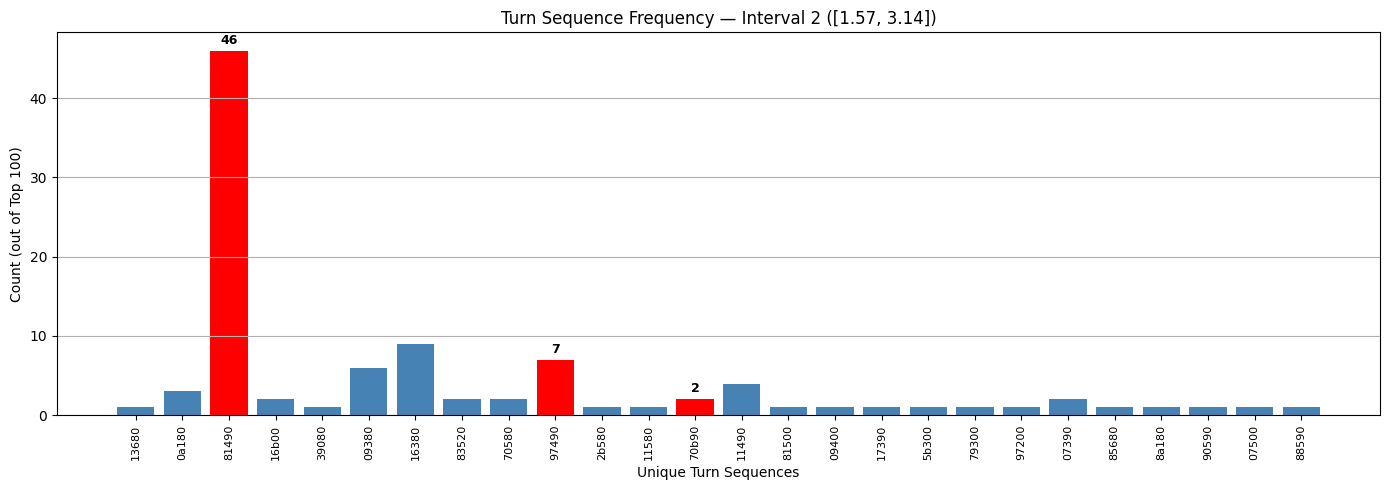

[('13680', -3.8376525417653227), ('0a180', -3.6700309438362595), ('81490', -3.6270534270172496), ('1b520', -3.6146525416236788), ('19720', -3.6146525413495887), ('1a700', -3.4827315214267225), ('18500', -3.482731521347662), ('05180', -3.4575484945286084), ('39080', -3.350320099122894), ('09380', -3.3338429551988664), ('83520', -3.2882078939640476), ('a9780', -3.2572078938768216), ('19400', -3.162254762870637), ('38390', -3.149320098804843), ('08390', -3.132842955449254), ('04190', -3.1265484942402653), ('70580', -3.1101955864654074), ('97490', -3.109165880986775), ('2b580', -3.106748202778982), ('11580', -3.1062547628596153), ('11490', -3.095731521524678), ('68580', -3.052491068315776), ('80580', -3.017594513997148), ('83680', -3.005253913314754), ('a0580', -3.0052539132437266), ('09400', -2.992926262124449), ('a3680', -2.9929133127522975), ('14090', -2.9884262970333526), ('2a400', -2.9279391263542696), ('20580', -2.911471194027139), ('2a490', -2.886916739296753), ('90580', -2.86462982

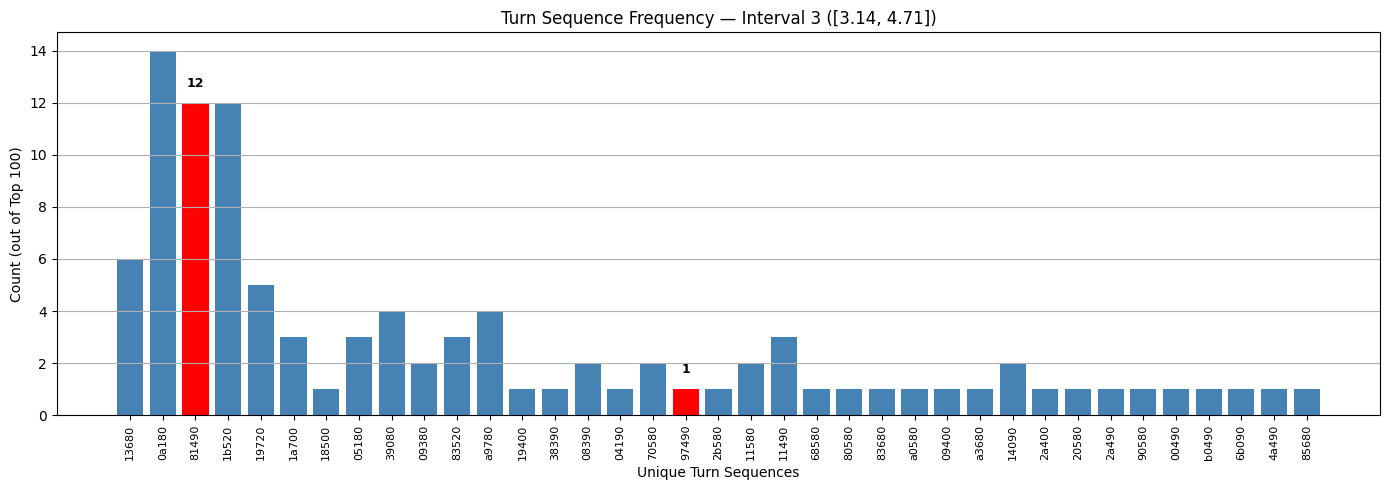

[('13680', -3.8376525417653227), ('81490', -3.6270534270172496), ('1b520', -3.6146525416236788), ('1a700', -3.4827315214267225), ('18500', -3.482731521347662), ('05180', -3.4575484945286084), ('39080', -3.350320099122894), ('09380', -3.3338429551988664), ('68b90', -3.1882432701656382), ('70580', -3.1101955864654074), ('97490', -3.109165880986775), ('11490', -3.095731521524678), ('68580', -3.052491068315776), ('83680', -3.005253913314754), ('81500', -3.001286873639309), ('a3680', -2.9929133127522975), ('36800', -2.927939126195609), ('2a490', -2.886916739296753), ('b3720', -2.880068470068318), ('90580', -2.8646298223928657), ('00490', -2.8599262618813786), ('93680', -2.852289221840979), ('90490', -2.8445008103789675), ('09590', -2.8387360547188036), ('a2490', -2.83216021018869), ('b0490', -2.8321602100288565), ('4a490', -2.829212220554336), ('82490', -2.819819609763867), ('85680', -2.787133241291946), ('90590', -2.745500810971559), ('07500', -2.7417693229396836)]
['13680', '81490', '1b52

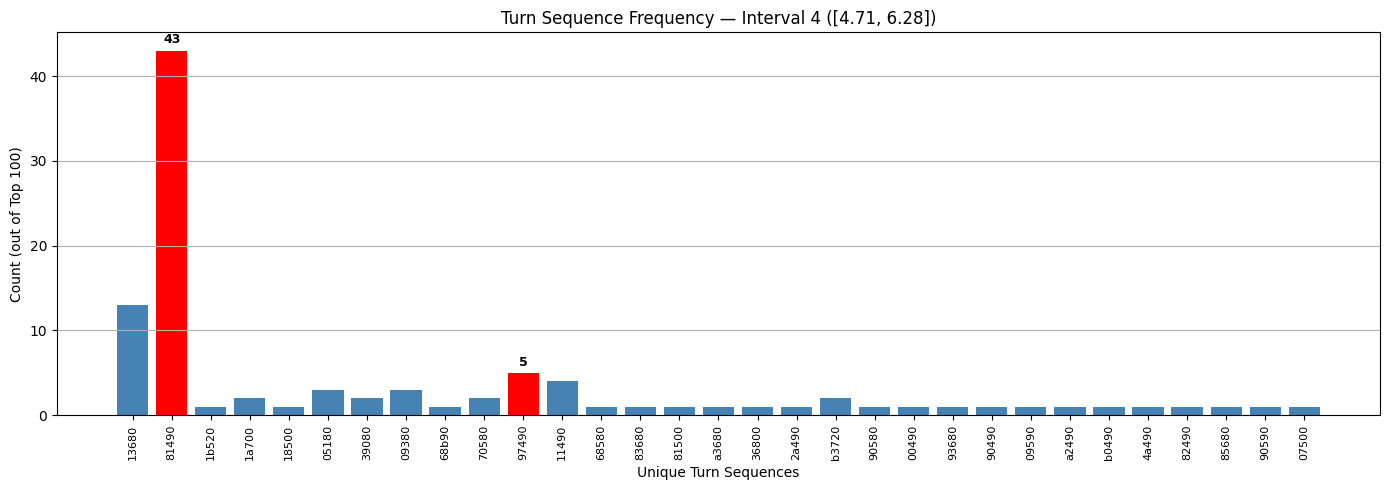

In [42]:
from collections import Counter
import matplotlib.pyplot as plt

# Top 5 classical solutions to highlight
cls_top5 = {'97490', 'a9720', '8b520', '70b90', '81490'}

for i in range(1, 5):
    top_mps_solns = top_mps_solns_by_interval[i]
    metadata = all_metadata[i]
    
    # Extract turn sequences as strings
    turn_strs = [''.join(sol[0]) for sol in top_mps_solns]
    # Compute the correct energies for these sequences
    peptide = Peptide(metadata['main_seq'])
    correct_bitstrings = [ProteinShapeDecoder(peptide, sol[1]).correct_bitstring for sol in top_mps_solns]
    energies = [_evaluate_sparsepauli(bitstring, qubit_op) for bitstring in correct_bitstrings]
    bitstring_energy_dict = {turn_strs[i]: energies[i] for i in range(len(turn_strs))}
    print(sorted(bitstring_energy_dict.items(), key=lambda x: x[1]))


    # Count occurrences
    turn_counts = Counter(turn_strs)
    # Sort the turn sequences based on their energies (ascending)
    sorted_turns = sorted(turn_counts.keys(), key=lambda x: bitstring_energy_dict[x])
    print(sorted_turns)
    # sorted_turns = sorted(turn_counts.keys())

    x_vals = list(range(len(sorted_turns)))
    y_vals = [turn_counts[turn] for turn in sorted_turns]
    
    # Color bars: red for top-5 CLS, blue otherwise
    bar_colors = ['red' if turn in cls_top5 else 'steelblue' for turn in sorted_turns]
    
    # Plot
    plt.figure(figsize=(14, 5))
    bars = plt.bar(x_vals, y_vals, color=bar_colors)
    
    # Annotate red bars with count
    for idx, turn in enumerate(sorted_turns):
        if turn in cls_top5:
            count = turn_counts[turn]
            plt.text(x_vals[idx], y_vals[idx] + 0.5, str(count), ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')
    
    plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
    plt.xlabel("Unique Turn Sequences")
    plt.ylabel("Count (out of Top 100)")
    plt.title(f"Turn Sequence Frequency — Interval {i} ({metadata['init_param_interval']})")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


In [39]:
top_cls_solns

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33],
 ['1a180', -30.33],
 ['68b90', -30.25],
 ['02180', -30.23],
 ['70390', -30.13],
 ['68390', -30.13],
 ['82180', -30.13],
 ['07490', -30.13],
 ['7b090', -29.56],
 ['91820', -29.56],
 ['b1a20', -29.56]]

In [45]:
def process_cls_turns(turns: str) -> list[int]:
    """Converts a string of turns to a list of integers. Note a maps to 10 and b to 11."""
    return [int(turn) if turn not in ['a', 'b'] else int(turn, 16) for turn in turns][::-1]

process_cls_turns(top_cls_solns[0][0])

[0, 9, 4, 7, 9]

In [55]:
qubit_op_1 = protein_folding_problem.qubit_op(r2_threshold=1.0, chunk=20)
qubit_op_less_accurate = protein_folding_problem.qubit_op(r2_threshold=0.999, chunk=20)
print(len(qubit_op_1))
print(len(qubit_op_less_accurate))

Beads 0 and 3 -- dist_op size: 35
h_op size @ k = 1: 35
Time taken to do composition @ k = 2: 0.0003330707550048828
h_op size @ k = 2: 60
Time taken to do composition @ k = 3: 0.0003299713134765625
h_op size @ k = 3: 62
Time taken to do composition @ k = 4: 0.00030994415283203125
h_op size @ k = 4: 64
Time taken to do composition @ k = 5: 0.00030517578125
h_op size @ k = 5: 64
Time taken to do composition @ k = 6: 0.0003020763397216797
h_op size @ k = 6: 64
Time taken to do composition @ k = 7: 0.0002980232238769531
h_op size @ k = 7: 64
Time taken to do composition @ k = 8: 0.00029921531677246094
h_op size @ k = 8: 64
Time taken to do composition @ k = 9: 0.00029921531677246094
h_op size @ k = 9: 64
Beads 0 and 4 -- dist_op size: 171
h_op size @ k = 1: 171
Time taken to do composition @ k = 2: 0.020039796829223633
h_op size @ k = 2: 835
Time taken to do composition @ k = 3: 0.015067100524902344
h_op size @ k = 3: 993
Time taken to do composition @ k = 4: 0.009422063827514648
h_op size

In [60]:
# For reference, compute energies of the top classical solutions based on this Hamiltonian
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:10]
peptide = Peptide(metadata['main_seq'])
correct_bitstrings = [turns_to_bitstring(peptide, process_cls_turns(turn_str)) for turn_str, _ in top_cls_solns]
# print(correct_bitstrings)
energies_1 = [_evaluate_sparsepauli(bitstring, qubit_op_1) for bitstring in correct_bitstrings]
energies_2 = [_evaluate_sparsepauli(bitstring, qubit_op_less_accurate) for bitstring in correct_bitstrings]
bitstring_energy_dict_1 = {top_cls_solns[i][0]: energies_1[i] for i in range(len(top_cls_solns))}
print("Energies based on Hamiltonian with r2_threshold=1.0:")
print(bitstring_energy_dict_1)
print("Energies based on Hamiltonian with r2_threshold=0.999:")
bitstring_energy_dict_2 = {top_cls_solns[i][0]: energies_2[i] for i in range(len(top_cls_solns))}
print(bitstring_energy_dict_2)

Energies based on Hamiltonian with r2_threshold=1.0:
{'97490': -3.0588739138148675, 'a9720': -3.051851363100635, '8b520': -3.054462537058652, '70b90': -3.048245050381448, '81490': -3.045910593370024, '31a20': -3.045340249268799, '31820': -3.046874214320796, '2b580': -3.042699849365669, '9a180': -3.040866880242276, '5b580': -3.029865135145818}
Energies based on Hamiltonian with r2_threshold=0.999:
{'97490': -3.109165880986775, 'a9720': -2.600442978228571, '8b520': -2.600442978450105, '70b90': -3.097165881107503, '81490': -3.6270534270172496, '31a20': -1.181614512601092, '31820': -1.1816145127894964, '2b580': -3.106748202778982, '9a180': -2.1325990361832643, '5b580': -2.6409042609039926}


In [24]:
# Load results for the mixed [π/2, π] ∪ [3π/2, 2π] run
mixed_path = "../res/fcc_hw/KLVFFA_2025-05-16-20-50-40_aer_simulator_matrix_product_state_mixed24"
mixed_metadata_path = os.path.join(mixed_path, "metadata.json")
mixed_opt_res_path = os.path.join(mixed_path, "opt_results.json")

with open(mixed_metadata_path, "r") as f:
    mixed_metadata = json.load(f)

with open(mixed_opt_res_path, "r") as f:
    mixed_opt_results = json.load(f)

print("✅ Loaded mixed interval [π/2, π] ∪ [3π/2, 2π] optimization results.")


✅ Loaded mixed interval [π/2, π] ∪ [3π/2, 2π] optimization results.


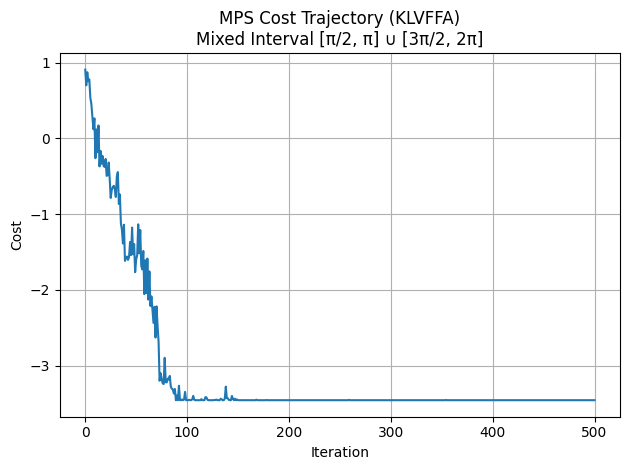

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(mixed_opt_results["cost_trajectory"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("MPS Cost Trajectory (KLVFFA)\nMixed Interval [π/2, π] ∪ [3π/2, 2π]")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
# Extract top 100 solutions from the mixed interval run
top_100_mixed = mixed_opt_results["top_solutions"][:100]

# Convert bitstrings to turn sequences
top_mps_solns_mixed = [
    [convert_bitstring_to_turns(bitstring, mixed_metadata["main_seq"]), bitstring, energy]
    for bitstring, energy in top_100_mixed
]

# Preview first 10 results
top_mps_solns_mixed[:10]


[['81490', '101101110100011100100110', -3.627053427231018],
 ['14900', '101101000011001001001000', -3.482731521573557],
 ['05180', '110101011000001010110001', -3.457548494465925],
 ['14900', '101101100011001001001000', -3.3517315215735572],
 ['05180', '110101111000001010110001', -3.326548494465925],
 ['19400', '001100000011000010100100', -3.1622547630415294],
 ['15800', '001100000011001010000100', -3.1622547629969016],
 ['05180', '110101001000001010110001', -3.1215484944659253],
 ['05180', '110101010000001010110001', -3.121548494465925],
 ['70580', '111001000001100000101001', -3.1101955868042395]]

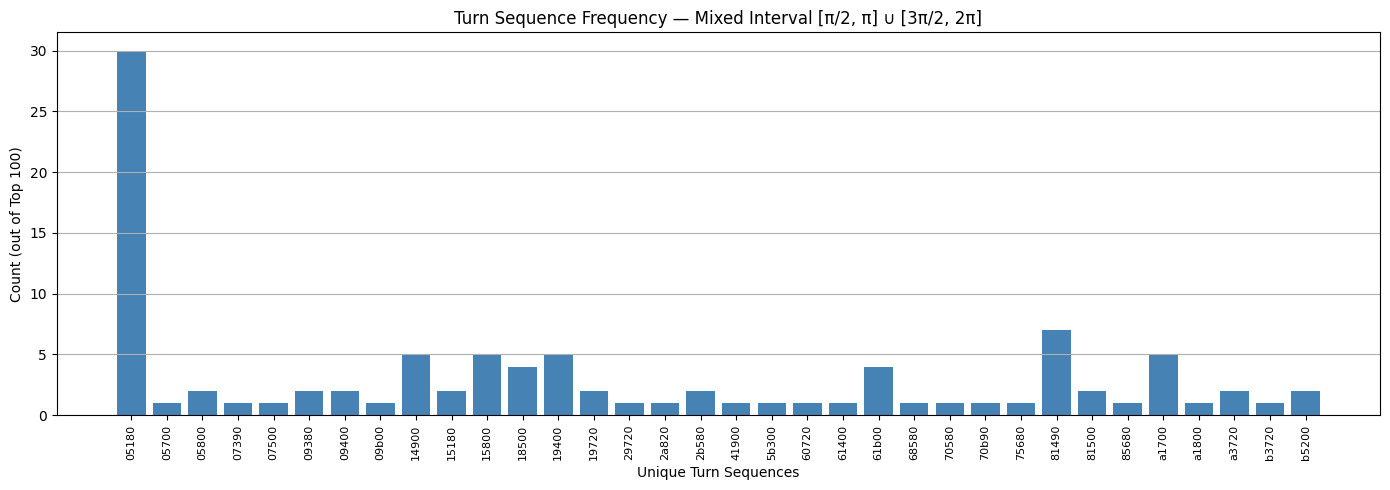

In [27]:
from collections import Counter
import matplotlib.pyplot as plt

# Top 3 classical solutions to highlight
cls_top3 = {'97490', 'a9720', '8b520'}

# Extract turn sequences as strings
turn_strs = [''.join(sol[0]) for sol in top_mps_solns_mixed]

# Count occurrences
turn_counts = Counter(turn_strs)
sorted_turns = sorted(turn_counts.keys())

x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[turn] for turn in sorted_turns]

# Color bars: red for top-3 CLS, blue otherwise
bar_colors = ['red' if turn in cls_top3 else 'steelblue' for turn in sorted_turns]

# Plot
plt.figure(figsize=(14, 5))
bars = plt.bar(x_vals, y_vals, color=bar_colors)

# Annotate red bars with count
for idx, turn in enumerate(sorted_turns):
    if turn in cls_top3:
        count = turn_counts[turn]
        plt.text(x_vals[idx], y_vals[idx] + 0.5, str(count), ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')

plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
plt.xlabel("Unique Turn Sequences")
plt.ylabel("Count (out of Top 100)")
plt.title("Turn Sequence Frequency — Mixed Interval [π/2, π] ∪ [3π/2, 2π]")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [29]:
# Load results for the mixed [π/2, π] 
interval2_path = "../res/fcc_hw/KLVFFA_2025-05-17-03-16-39_aer_simulator_matrix_product_state_interval2"
interval2_metadata_path = os.path.join(interval2_path, "metadata.json")
interval2_opt_res_path = os.path.join(interval2_path, "opt_results.json")

with open(interval2_metadata_path, "r") as f:
    interval2_metadata = json.load(f)

with open(interval2_opt_res_path, "r") as f:
    interval2_opt_results = json.load(f)

print("✅ Loaded interval [π/2, π]  optimization results.")

✅ Loaded interval [π/2, π]  optimization results.


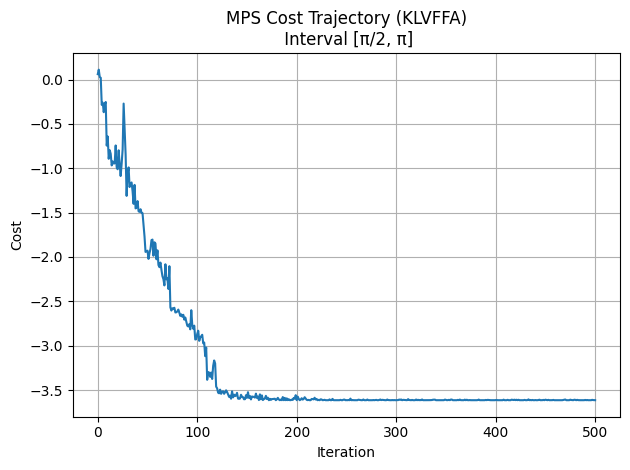

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(interval2_opt_results["cost_trajectory"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("MPS Cost Trajectory (KLVFFA)\n Interval [π/2, π]")
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# Extract top 100 solutions from the mixed interval run
top_100_interval2 = interval2_opt_results["top_solutions"][:100]

# Convert bitstrings to turn sequences
top_mps_solns_interval2 = [
    [convert_bitstring_to_turns(bitstring, interval2_metadata["main_seq"]), bitstring, energy]
    for bitstring, energy in top_100_interval2
]

# Preview first 10 results
top_mps_solns_interval2[:10]

[['13680', '011101100011001111010101', -3.7066525415337845],
 ['19720', '001001011011000010011011', -3.6146525417956115],
 ['19720', '001001111011000010011011', -3.483652541795612],
 ['1b520', '001001111011001110101011', -3.4836525411364585],
 ['18500', '101101000011000001101000', -3.482731521538029],
 ['13680', '001101000011001111010101', -3.4336525415337835],
 ['19720', '001001011111000010011011', -3.365652541795612],
 ['19720', '001001001011000010011011', -3.278652541795612],
 ['19720', '001001010011000010011011', -3.278652541795612],
 ['a9780', '011110010011010010011001', -3.2572078941862945]]

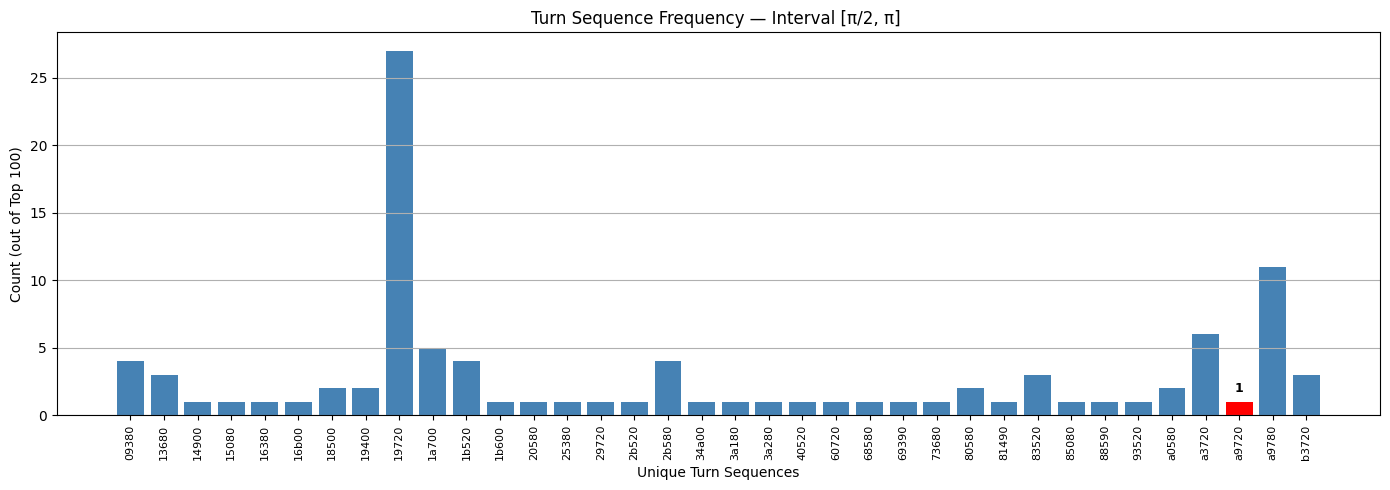

In [34]:
from collections import Counter
import matplotlib.pyplot as plt

# Top 3 classical solutions to highlight
cls_top3 = {'97490', 'a9720', '8b520'}

# Extract turn sequences as strings
turn_strs = [''.join(sol[0]) for sol in top_mps_solns_interval2]

# Count occurrences
turn_counts = Counter(turn_strs)
sorted_turns = sorted(turn_counts.keys())

x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[turn] for turn in sorted_turns]

# Color bars: red for top-3 CLS, blue otherwise
bar_colors = ['red' if turn in cls_top3 else 'steelblue' for turn in sorted_turns]

# Plot
plt.figure(figsize=(14, 5))
bars = plt.bar(x_vals, y_vals, color=bar_colors)

# Annotate red bars with count
for idx, turn in enumerate(sorted_turns):
    if turn in cls_top3:
        count = turn_counts[turn]
        plt.text(x_vals[idx], y_vals[idx] + 0.5, str(count), ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')

plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
plt.xlabel("Unique Turn Sequences")
plt.ylabel("Count (out of Top 100)")
plt.title("Turn Sequence Frequency — Interval [π/2, π] ")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [36]:
# Load results for the mixed [π/2, π]  data/protein-folding-qc/res/fcc_hw/KLVFFA_2025-05-18-22-52-04_aer_simulator_matrix_product_state_interval2rerun1
interval2rerun1_path = "../res/fcc_hw/KLVFFA_2025-05-18-22-52-04_aer_simulator_matrix_product_state_interval2rerun1"
interval2rerun1_metadata_path = os.path.join(interval2rerun1_path, "metadata.json")
interval2rerun1_opt_res_path = os.path.join(interval2rerun1_path, "opt_results.json")

with open(interval2rerun1_metadata_path, "r") as f:
    interval2rerun1_metadata = json.load(f)

with open(interval2rerun1_opt_res_path, "r") as f:
    interval2rerun1_opt_results = json.load(f)

print("✅ Loaded interval rerun1 [π/2, π]  optimization results.")

✅ Loaded interval rerun1 [π/2, π]  optimization results.


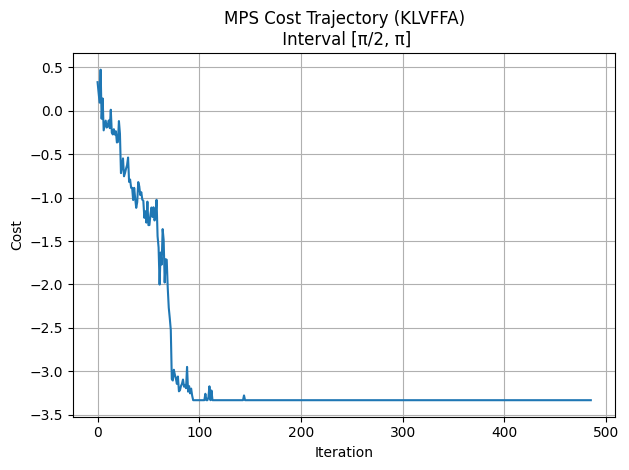

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(interval2rerun1_opt_results["cost_trajectory"])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("MPS Cost Trajectory (KLVFFA)\n Interval [π/2, π]")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
# Extract top 100 solutions from the mixed interval run
top_100_interval2rerun1 = interval2rerun1_opt_results["top_solutions"][:100]

# Convert bitstrings to turn sequences
top_mps_solns_interval2rerun1 = [
    [convert_bitstring_to_turns(bitstring, interval2rerun1_metadata["main_seq"]), bitstring, energy]
    for bitstring, energy in top_100_interval2rerun1
]

# Preview first 10 results
top_mps_solns_interval2rerun1[:10]

[['81490', '101101110100011100100110', -3.627053427231018],
 ['1b520', '001001111011001110101011', -3.4836525411364585],
 ['81490', '101101110000011100100110', -3.3780534272310176],
 ['0a180', '011011000000001101110001', -3.3340309433137407],
 ['16380', '111100000011000101111101', -3.3314999294410685],
 ['81490', '101101111100011100100110', -3.2910534272310183],
 ['81490', '111101110100011100100110', -3.2230534272310183],
 ['16380', '111100100011000101111101', -3.2004999294410683],
 ['19400', '001100000011000010100100', -3.1622547630415294],
 ['15800', '001100000011001010000100', -3.1622547629969016]]

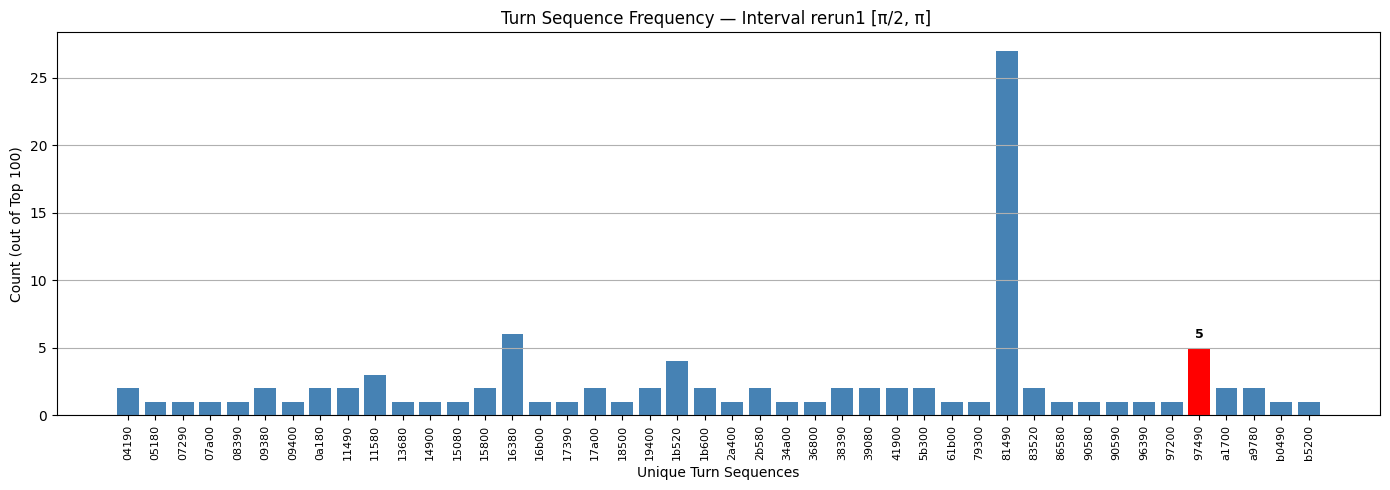

In [39]:
from collections import Counter
import matplotlib.pyplot as plt

# Top 3 classical solutions to highlight
cls_top3 = {'97490', 'a9720', '8b520'}

# Extract turn sequences as strings
turn_strs = [''.join(sol[0]) for sol in top_mps_solns_interval2rerun1]

# Count occurrences
turn_counts = Counter(turn_strs)
sorted_turns = sorted(turn_counts.keys())

x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[turn] for turn in sorted_turns]

# Color bars: red for top-3 CLS, blue otherwise
bar_colors = ['red' if turn in cls_top3 else 'steelblue' for turn in sorted_turns]

# Plot
plt.figure(figsize=(14, 5))
bars = plt.bar(x_vals, y_vals, color=bar_colors)

# Annotate red bars with count
for idx, turn in enumerate(sorted_turns):
    if turn in cls_top3:
        count = turn_counts[turn]
        plt.text(x_vals[idx], y_vals[idx] + 0.5, str(count), ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')

plt.xticks(ticks=x_vals, labels=sorted_turns, rotation=90, fontsize=8)
plt.xlabel("Unique Turn Sequences")
plt.ylabel("Count (out of Top 100)")
plt.title("Turn Sequence Frequency — Interval rerun1 [π/2, π] ")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
